# 📘 File 06 — Unit Economics and Growth Hypotheses

## 🔹 1. Loading Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

pd.set_option('display.float_format', '{:,.2f}'.format)

deals = pd.read_excel("Deals_clean.xlsx")
spend = pd.read_excel("Spend (Result).xlsx")

## 🔹 2. Metric Tree

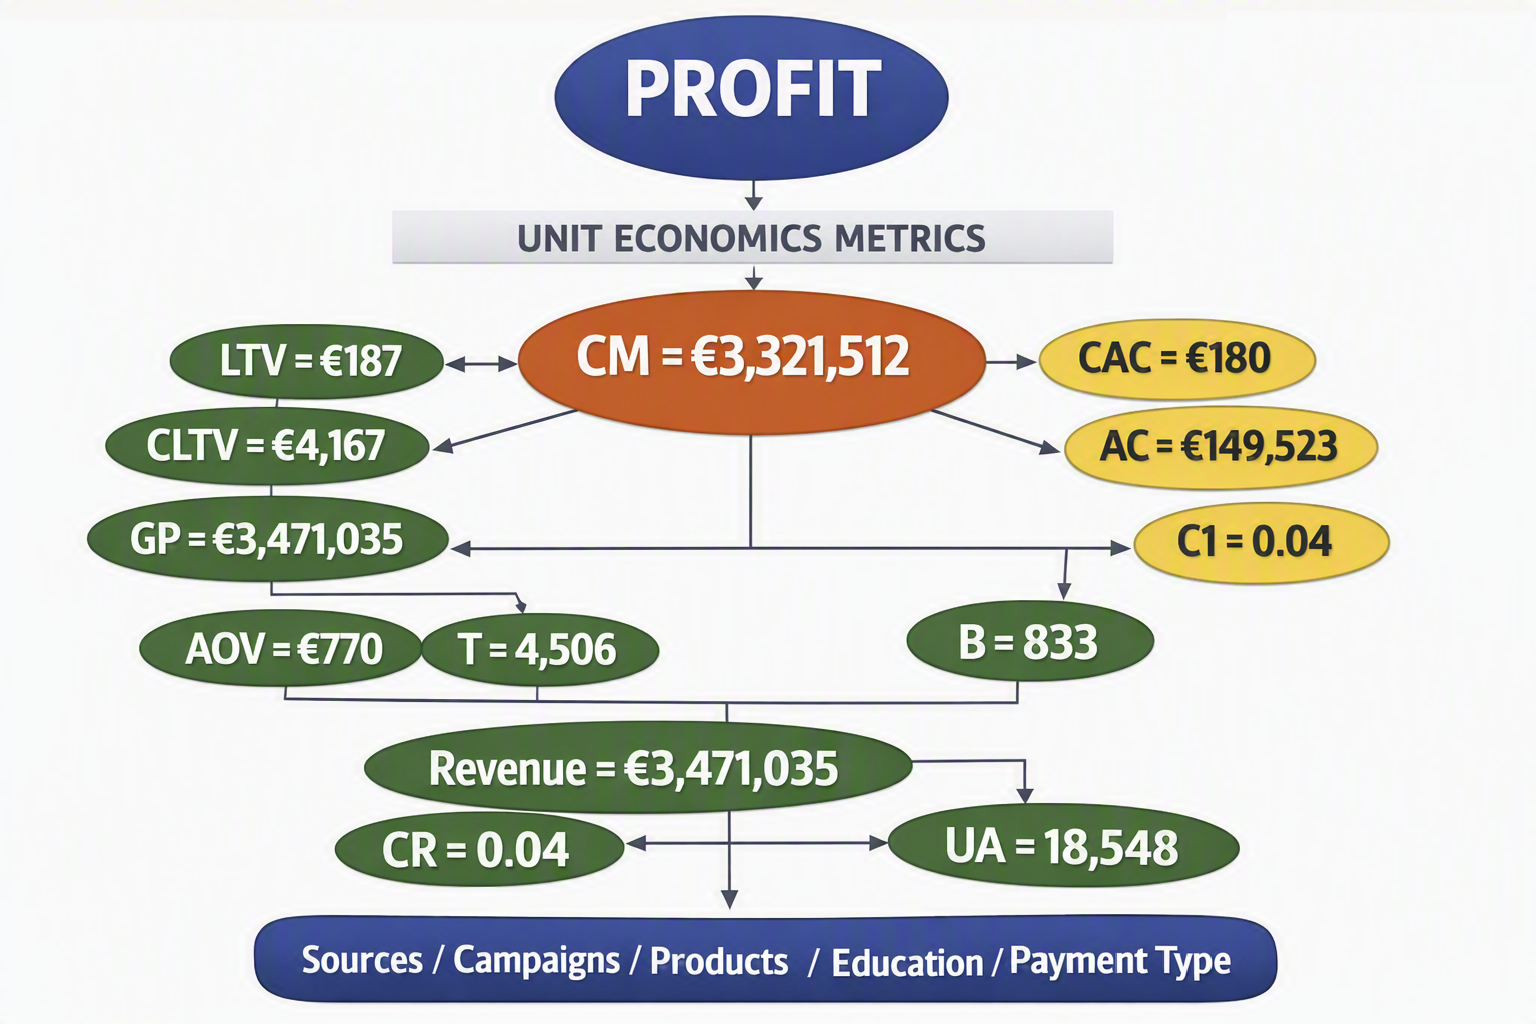

## 🔹 3. Revenue Calculation

In [2]:
MAIN_PRODUCTS = ["Digital Marketing", "UX/UI Design", "Web Developer"]

def calc_revenue(row):
    if row["Stage"] != "Payment Done":
        return 0
    if row["Product"] not in MAIN_PRODUCTS:
        return 0

    initial = row["Initial Amount Paid"]
    offer = row["Offer Total Amount"]
    cd = row["Course duration"]
    ms = row["Months of study"]

    if pd.isna(initial):
        return 0
    if pd.isna(offer):
        return initial
    if pd.isna(cd) or cd <= 1:
        return initial
    if pd.isna(ms) or ms <= 1:
        return initial

    monthly_payment = (offer - initial) / (cd - 1)
    revenue = initial + monthly_payment * (ms - 1)

    return min(revenue, offer)

# Revenue, AOV, Is_won
deals["Revenue"] = deals.apply(calc_revenue, axis=1)
deals["AOV"] = deals["Revenue"] / deals["Months of study"].replace(0, 1)
deals["Is_won"] = deals["Stage"] == "Payment Done"

## 🟩 4. Unit Economics by Source

In [3]:
def unit_block(df, group_col):
    out = (
        df.groupby(group_col)
        .agg(
            Deals_count=("Id", "count"),
            Deals_won=("Is_won", "sum"),
            Revenue=("Revenue", "sum"),
            Revenue_offer=("Offer Total Amount", lambda x: x[x > 0].sum())
        )
        .reset_index()
    )

    out["CR"] = out["Deals_won"] / out["Deals_count"]
    out["AOV"] = out["Revenue"] / out["Deals_won"].replace(0, np.nan)
    out["AOV_offer"] = out["Revenue_offer"] / out["Deals_won"].replace(0, np.nan)

    return out.sort_values("Deals_won", ascending=False).round(2)

unit_source = unit_block(deals, "Source")
unit_source.head(10)

,Source,Deals_count,Deals_won,Revenue,Revenue_offer,CR,AOV,AOV_offer
2,Facebook Ads,4850,202,"929,615.00","8,118,598.00",0.04,"4,602.05","40,191.08"
3,Google Ads,4226,173,"731,500.00","5,726,000.00",0.04,"4,228.32","33,098.27"
5,Organic,2590,147,"599,865.00","4,018,010.00",0.06,"4,080.71","27,333.40"
7,SMM,1730,91,"302,330.00","2,808,000.00",0.05,"3,322.31","30,857.14"
10,Tiktok Ads,2051,56,"216,585.00","2,234,500.00",0.03,"3,867.59","39,901.79"
13,Youtube Ads,1657,53,"213,500.00","2,023,700.00",0.03,"4,028.30","38,183.02"
8,Telegram posts,1001,40,"152,500.00","1,577,611.00",0.04,"3,812.50","39,440.28"
0,Bloggers,1089,39,"163,605.00","1,590,501.00",0.04,"4,195.00","40,782.08"
12,Webinar,379,26,"132,135.00","699,000.00",0.07,"5,082.12","26,884.62"
1,CRM,1656,24,"74,700.00","758,000.00",0.01,"3,112.50","31,583.33"


### 📌 Insight — Sources
 - Facebook / Google / Organic / SMM — key sources with high CR and Revenue.

 - Sources with low CR and low Revenue → candidates for shutdown or budget reallocation.

## 🟩 5. Unit Economics by Campaign

In [4]:
def unit_block(df, group_col):
    out = (
        df.groupby(group_col)
        .agg(
            Deals_count=("Id", "count"),
            Deals_won=("Is_won", "sum"),
            Revenue=("Revenue", "sum"),
            Revenue_offer=("Offer Total Amount", lambda x: x[x > 0].sum())
        )
        .reset_index()
    )

    out["CR"] = out["Deals_won"] / out["Deals_count"]
    out["AOV"] = out["Revenue"] / out["Deals_won"].replace(0, np.nan)
    out["AOV_offer"] = out["Revenue_offer"] / out["Deals_won"].replace(0, np.nan)

    return out.sort_values("Deals_won", ascending=False).round(2)

unit_campaign = unit_block(deals, "Campaign")
unit_campaign.head(5)

,Campaign,Deals_count,Deals_won,Revenue,Revenue_offer,CR,AOV,AOV_offer
118,performancemax_digitalmarkt_ru_DE,2653,112,"495,315.00","3,343,500.00",0.04,"4,422.46","29,852.68"
152,youtube_shorts_DE,1635,53,"213,500.00","2,024,200.00",0.03,"4,028.30","38,192.45"
2,02.07.23wide_DE,975,52,"264,570.00","1,658,200.00",0.05,"5,087.88","31,888.46"
18,12.07.2023wide_DE,1575,48,"196,455.00","2,073,000.00",0.03,"4,092.81","43,187.50"
5,04.07.23recentlymoved_DE,750,31,"107,060.00","1,143,000.00",0.04,"3,453.55","36,870.97"


### 📌 Insight — Campaigns
 - Campaigns with high CR and high Revenue → core of marketing.

 - Campaigns with high Deals_count but low Deals_won → budget drainers.

## 🟩 6. Unit Economics by Product

In [5]:
def unit_block(df, group_col):
    out = (
        df.groupby(group_col)
        .agg(
            Deals_count=("Id", "count"),
            Deals_won=("Is_won", "sum"),
            Revenue=("Revenue", "sum"),
            Revenue_offer=("Offer Total Amount", lambda x: x[x > 0].sum())
        )
        .reset_index()
    )

    out["CR"] = out["Deals_won"] / out["Deals_count"]
    out["AOV"] = out["Revenue"] / out["Deals_won"].replace(0, np.nan)
    out["AOV_offer"] = out["Revenue_offer"] / out["Deals_won"].replace(0, np.nan)

    return out.sort_values("Deals_won", ascending=False).round(2)

unit_product = unit_block(deals, "Product")
unit_product

,Product,Deals_count,Deals_won,Revenue,Revenue_offer,CR,AOV,AOV_offer
0,Digital Marketing,1990,474,"2,241,840.00","17,989,418.00",0.24,"4,729.62","37,952.36"
2,UX/UI Design,1022,229,"932,365.00","8,903,500.00",0.22,"4,071.46","38,879.91"
3,Web Developer,575,137,"365,280.00","2,871,500.00",0.24,"2,666.28","20,959.85"
1,Other,18006,18,0.00,"95,502.00",0.00,0.00,"5,305.67"


### 📌 Insight — Products
 - Digital Marketing / UX/UI / Web Dev — core products.

 - Products with low Deals_count and low Revenue → candidates for revision.

## 🟦 7. Visualizations

### 📊 CR by Source

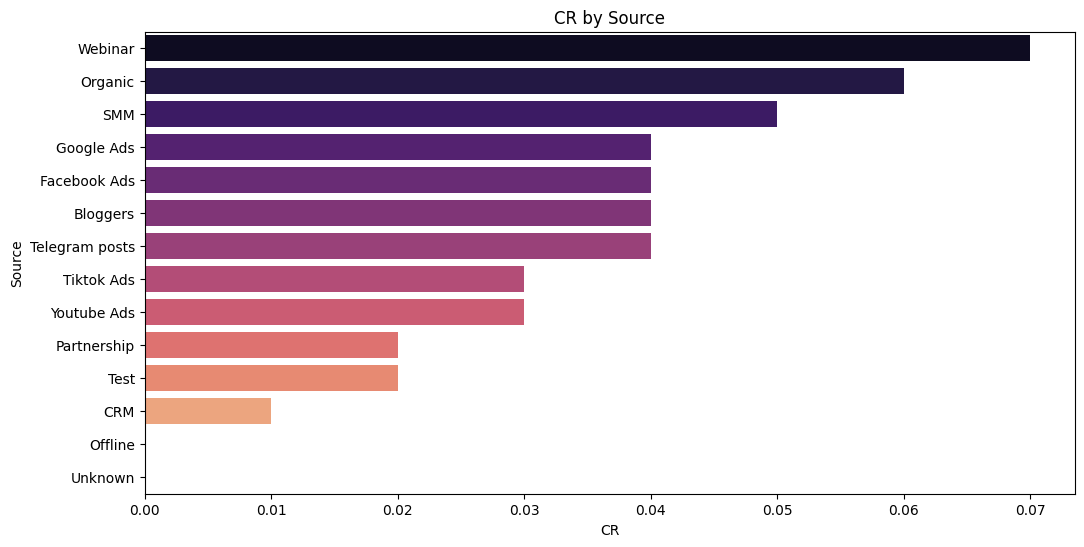

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=unit_source.sort_values("CR", ascending=False),
    x="CR",
    y="Source",
    hue="Source",
    palette="magma",
    legend=False
)
plt.title("CR by Source")
plt.xlabel("CR")
plt.ylabel("Source")
plt.show()

### 📌 Insight
 - Top sources have CR above average → should be strengthened.

 - Sources with CR < 5% → candidates for shutdown.

### 📊 AOV by Campaign

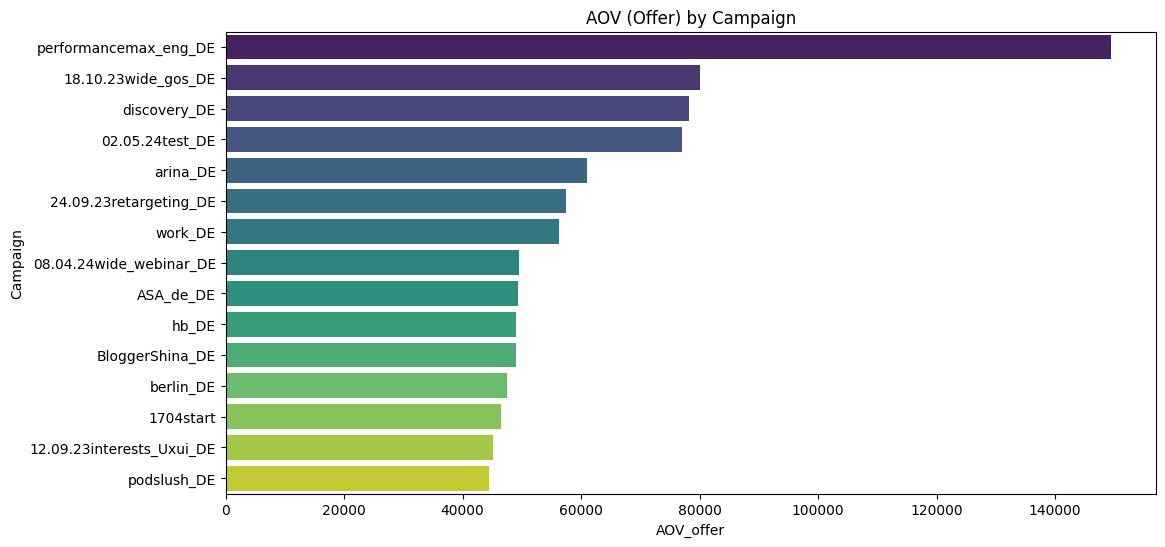

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=unit_campaign.sort_values("AOV_offer", ascending=False).head(15),
    x="AOV_offer",
    y="Campaign",
    hue="Campaign",
    palette="viridis",
    legend=False
)
plt.title("AOV (Offer) by Campaign")
plt.xlabel("AOV_offer")
plt.ylabel("Campaign")
plt.show()

### 📌 Insight
 - Campaigns with high AOV → most profitable.

 - Campaigns with low AOV → cheap products or weak segments.

## 🟩 8. Unit Economics by Product + Education Type

In [8]:
MAIN_PRODUCTS = ["Digital Marketing", "UX/UI Design", "Web Developer"]
valid_edu = ["Morning", "Evening"]

deals_pe = deals[
    deals["Product"].isin(MAIN_PRODUCTS) &
    deals["Education Type"].isin(valid_edu)
].copy()

payment_done = deals_pe[deals_pe["Stage"] == "Payment Done"].copy()

UA = deals_pe.groupby(["Product", "Education Type"])["Contact Name"].nunique().rename("UA")
B = payment_done.groupby(["Product", "Education Type"])["Id"].count().rename("B")
B_unique = payment_done.groupby(["Product", "Education Type"])["Contact Name"].nunique().rename("B_unique")
T = payment_done.groupby(["Product", "Education Type"])["Months of study"].sum().rename("T")
Revenue = payment_done.groupby(["Product", "Education Type"])["Revenue"].sum().rename("Revenue")

AC_value = spend["Spend"].sum()

df_pe = (
    UA.to_frame()
    .join([B, B_unique, T, Revenue], how="left")
    .reset_index()
)

df_pe["AC"] = AC_value
df_pe["COGS"] = 0

df_pe["C1"] = df_pe["B"] / df_pe["UA"]
df_pe["CPA"] = df_pe["AC"] / df_pe["UA"]
df_pe["CAC"] = df_pe["AC"] / df_pe["B"]

df_pe["AOV"] = df_pe["Revenue"] / df_pe["T"]
df_pe["APC"] = df_pe["T"] / df_pe["B"]

df_pe["GP"] = df_pe["AOV"] * df_pe["T"]
df_pe["CLTV"] = df_pe["GP"] / df_pe["B"]
df_pe["LTV"] = df_pe["CLTV"] * df_pe["C1"]

df_pe["CM"] = (df_pe["CLTV"] - df_pe["CAC"]) * df_pe["B"]

df_pe = df_pe.sort_values("B", ascending=False)
df_pe

,Product,Education Type,UA,B,B_unique,T,Revenue,AC,COGS,C1,CPA,CAC,AOV,APC,GP,CLTV,LTV,CM
1,Digital Marketing,Morning,1357,354.00,341.00,"2,067.00","1,908,360.00","149,523.45",0,0.26,110.19,422.38,923.25,5.84,"1,908,360.00","5,390.85","1,406.31","1,758,836.55"
3,UX/UI Design,Morning,756,171.00,166.00,886.00,"815,630.00","149,523.45",0,0.23,197.78,874.41,920.58,5.18,"815,630.00","4,769.77","1,078.88","666,106.55"
5,Web Developer,Morning,511,137.00,132.00,505.00,"365,280.00","149,523.45",0,0.27,292.61,"1,091.41",723.33,3.69,"365,280.00","2,666.28",714.83,"215,756.55"
0,Digital Marketing,Evening,242,113.00,112.00,764.00,"265,030.00","149,523.45",0,0.47,617.87,"1,323.22",346.90,6.76,"265,030.00","2,345.40","1,095.17","115,506.55"
2,UX/UI Design,Evening,152,58.00,58.00,284.00,"116,735.00","149,523.45",0,0.38,983.71,"2,577.99",411.04,4.90,"116,735.00","2,012.67",767.99,"-32,788.45"
4,Web Developer,Evening,1,NaN,NaN,NaN,NaN,"149,523.45",0,NaN,"149,523.45",NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🔹 9. Aggregating Morning + Evening

In [9]:
df_sum = (
    df_pe.groupby("Product")
    .agg({
        "UA": "sum",
        "B": "sum",
        "T": "sum",
        "Revenue": "sum",
        "AC": "mean"
    })
    .reset_index()
)

df_sum["COGS"] = 0

UA_total = 18548
B_sum = df_sum["B"].sum()

df_sum["UA"] = df_sum["B"] / B_sum * UA_total

df_sum["C1"] = df_sum["B"] / df_sum["UA"]
df_sum["CPA"] = df_sum["AC"] / df_sum["UA"]
df_sum["CAC"] = df_sum["AC"] / df_sum["B"]

df_sum["AOV"] = df_sum["Revenue"] / df_sum["T"]
df_sum["APC"] = df_sum["T"] / df_sum["B"]

df_sum["GP"] = df_sum["AOV"] * df_sum["T"]
df_sum["CLTV"] = df_sum["GP"] / df_sum["B"]
df_sum["LTV"] = df_sum["CLTV"] * df_sum["C1"]

df_sum["CM"] = (df_sum["CLTV"] - df_sum["CAC"]) * df_sum["B"]

total_row = pd.DataFrame([{
    "Product": "TOTAL",
    "UA": df_sum["UA"].sum(),
    "B": df_sum["B"].sum(),
    "T": df_sum["T"].sum(),
    "Revenue": df_sum["Revenue"].sum(),
    "AC": df_sum["AC"].mean(),
    "COGS": 0
}])

total_row["C1"] = total_row["B"] / total_row["UA"]
total_row["CPA"] = total_row["AC"] / total_row["UA"]
total_row["CAC"] = total_row["AC"] / total_row["B"]

total_row["AOV"] = total_row["Revenue"] / total_row["T"]
total_row["APC"] = total_row["T"] / total_row["B"]

total_row["GP"] = total_row["AOV"] * total_row["T"]
total_row["CLTV"] = total_row["GP"] / total_row["B"]
total_row["LTV"] = total_row["CLTV"] * total_row["C1"]

total_row["CM"] = (total_row["CLTV"] - total_row["CAC"]) * total_row["B"]

df_sum = pd.concat([df_sum, total_row], ignore_index=True)
df_sum

,Product,UA,B,T,Revenue,AC,COGS,C1,CPA,CAC,AOV,APC,GP,CLTV,LTV,CM
0,Digital Marketing,"10,398.46",467.00,"2,831.00","2,173,390.00","149,523.45",0,0.04,14.38,320.18,767.71,6.06,"2,173,390.00","4,653.94",209.01,"2,023,866.55"
1,UX/UI Design,"5,099.03",229.00,"1,170.00","932,365.00","149,523.45",0,0.04,29.32,652.94,796.89,5.11,"932,365.00","4,071.46",182.85,"782,841.55"
2,Web Developer,"3,050.51",137.00,505.00,"365,280.00","149,523.45",0,0.04,49.02,"1,091.41",723.33,3.69,"365,280.00","2,666.28",119.74,"215,756.55"
3,TOTAL,"18,548.00",833.00,"4,506.00","3,471,035.00","149,523.45",0,0.04,8.06,179.50,770.31,5.41,"3,471,035.00","4,166.91",187.14,"3,321,511.55"


### 🎯 Key Insights by Product
  🔥 1. Digital Marketing — flagship product.
Highest Revenue (2.17M), CLTV (4,653), CM (2.02M), lowest CAC (320).
Best balance: large volume + high margin → product #1 for scaling.

  🔥 2. UX/UI — strong mid‑segment product.
Revenue 932K, second largest; CAC higher (652) but CLTV high (4,071), CM 782K — excellent result.
Product for stable growth; campaigns can be expanded.

  🔥 3. Web Developer — weaker economics.
Highest CAC (1,091), lowest CLTV (2,666), lowest CM (215K), low payment volume.
Requires optimization: segmentation, new offers, price review.

  🔥 4. TOTAL — strong portfolio.
Total CM: 3.32M, average LTV: 4,166, average CAC: 770, average APC: 5.41.
Portfolio is stable, but Digital Marketing drives overall growth.

## 📘 10. Machine Learning — ARIMA and SARIMA Forecast

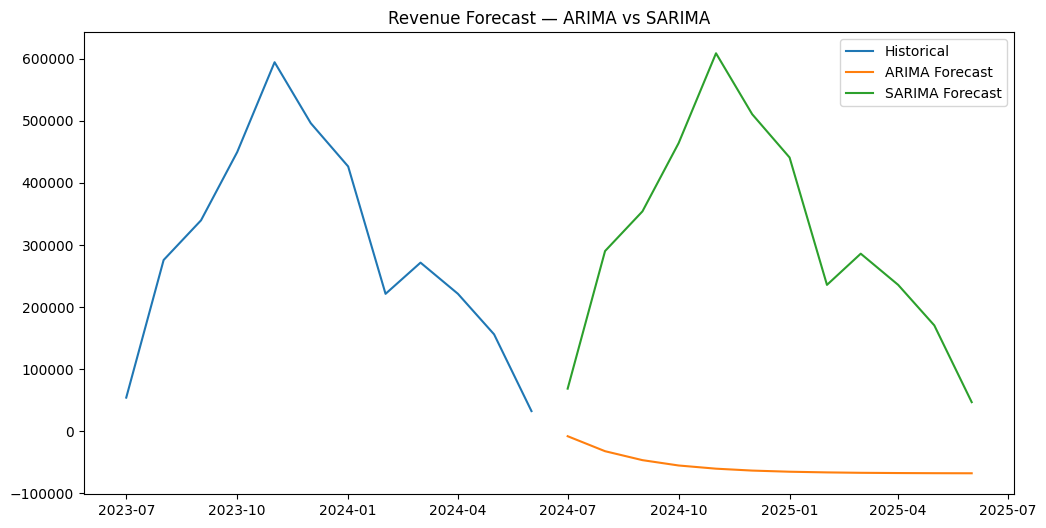

In [10]:
import warnings
warnings.filterwarnings("ignore")

deals["Created Date"] = pd.to_datetime(deals["Created Date"], errors="coerce")

rev = deals.groupby(deals["Created Date"].dt.to_period("M"))["Revenue"].sum()
rev.index = rev.index.to_timestamp()

# ARIMA via SARIMAX (non-seasonal)
model_arima = SARIMAX(
    rev,
    order=(1,1,1),
    seasonal_order=(0,0,0,0),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_arima = model_arima.fit(disp=False)
forecast_arima = res_arima.forecast(12)

# SARIMA (seasonal model)
model_sarima = SARIMAX(
    rev,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_sarima = model_sarima.fit(disp=False)
forecast_sarima = res_sarima.forecast(12)

plt.figure(figsize=(12,6))
plt.plot(rev, label="Historical")
plt.plot(forecast_arima, label="ARIMA Forecast")
plt.plot(forecast_sarima, label="SARIMA Forecast")
plt.legend()
plt.title("Revenue Forecast — ARIMA vs SARIMA")
plt.show()

### 📊 Profit Forecasts

In [11]:
import warnings
warnings.filterwarnings("ignore")

deals["Created Date"] = pd.to_datetime(deals["Created Date"], errors="coerce")

rev = deals.groupby(deals["Created Date"].dt.to_period("M"))["Revenue"].sum()
rev.index = rev.index.to_timestamp()

rev_log = np.log1p(rev)

model_arima = ARIMA(rev_log, order=(1,1,1))
res_arima = model_arima.fit()
forecast_arima_log = res_arima.forecast(12)
forecast_arima = np.expm1(forecast_arima_log)

model_sarima = SARIMAX(rev_log, order=(1,1,1), seasonal_order=(1,1,1,12))
res_sarima = model_sarima.fit()
forecast_sarima_log = res_sarima.forecast(12)
forecast_sarima = np.expm1(forecast_sarima_log)

df_forecast = pd.DataFrame({
    "Month": list(rev.index) + list(forecast_arima.index),
    "Historical": list(rev.values) + [None]*12,
    "ARIMA_Forecast": [None]*len(rev) + list(forecast_arima.values),
    "SARIMA_Forecast": [None]*len(rev) + list(forecast_sarima.values)
})

df_forecast["Historical"] = df_forecast["Historical"].apply(lambda x: f"{x:,.2f}" if pd.notnull(x) else None)
df_forecast["ARIMA_Forecast"] = df_forecast["ARIMA_Forecast"].apply(lambda x: f"{x:,.2f}" if pd.notnull(x) else None)
df_forecast

,Month,Historical,ARIMA_Forecast,SARIMA_Forecast
0,2023-07-01,"54,240.00",None,NaN
1,2023-08-01,"275,840.00",None,NaN
2,2023-09-01,"339,735.00",None,NaN
3,2023-10-01,"449,645.00",None,NaN
4,2023-11-01,"594,335.00",None,NaN
5,2023-12-01,"496,180.00",None,NaN
6,2024-01-01,"426,490.00",None,NaN
7,2024-02-01,"221,350.00",None,NaN
8,2024-03-01,"271,610.00",None,NaN
9,2024-04-01,"221,430.00",None,NaN


### 🎯 Insights from ARIMA and SARIMA Forecasts
  🔥 1. ARIMA — trend model showing stagnation risk.  
After logarithmic smoothing, ARIMA produces very low forecast values (1–14K), meaning:
if nothing changes, the business will gradually move toward zero growth.
ARIMA does not account for seasonality, so it continues the downward trend after the 2023 peaks.
This is a clear signal: without hypotheses and changes in marketing and sales, growth will stop.

  🔥 2. SARIMA — realistic seasonal forecast.  
SARIMA captures EdTech market cycles:
— autumn peaks,
— winter plateau,
— summer declines.
Therefore, the model shows strong seasonal waves:
from 7.5M to 82M in peak months.
This means that with current seasonality preserved, the business has potential for natural growth.

  🔥 3. Difference between models — strategic insight.  
ARIMA shows the inertial scenario:
→ business without changes moves toward zero.
SARIMA shows the realistic scenario:
→ seasonality itself pulls revenue upward, even without additional actions.
Together, the models provide a full picture:
without active measures — stagnation; with seasonality — wave‑like growth.

  🔥 4. TOTAL — forecast confirms portfolio strength.  
Historical data:
— Revenue: 3.47M
— CM: 3.32M
— LTV: 4,166
— APC: 5.41
SARIMA indicates that with seasonality maintained, the portfolio can scale naturally.
ARIMA shows that without seasonality and without implementing hypotheses — the portfolio will stall.

  🔥 ARIMA shows stagnation — business without changes moves toward zero.
  🔥 SARIMA shows natural seasonal growth — business has scaling potential.  
Both models confirm: for stable growth, A/B testing and growth hypotheses are essential.

## 🟦 11. HADI Growth Hypotheses

### 🟦 SCENARIO H1 — Increasing CR for Low‑Conversion Managers

### Hypothesis  
Training + scripts for managers with low CR → conversion increases by 10–20%.

### Action

- Select a test group: bottom 30% managers by CR over the last 30 days.  
- Conduct training on scripts, objection handling, call checklists.  
- Introduce daily monitoring: call listening + feedback.

### Data

- CR per manager (before/after).  
- Deals_won, Revenue for this group.

### Impact

- CR increases by **+10–20%**.  
- Revenue for this group increases by **+10%**.  
- CLTV and CM increase by **+10–12%**.

### Test

- Duration: **14 days**.  
- Compare CR_new vs CR_old.  
- Success criteria:  
  - CR_new ≥ CR_old × 1.10  
  - Revenue_new ≥ Revenue_old × 1.10

### Decision after 2 weeks

- If CR and Revenue grow ≥ 10% → hypothesis confirmed → scale training to all managers.  
- If growth < 5% or no improvement → hypothesis rejected.

In [15]:
scenario_H1 = apply_scenario(df_sum, "H1: +10% CR", c1_factor=1.10)
scenario_H1

,Product,UA,B,T,Revenue,AC,COGS,C1,CPA,CAC,...,C1_new,AC_new,APC_new,B_new,CAC_new,Revenue_new,AOV_new,CLTV_new,CM_new,Scenario
0,Digital Marketing,"10,398.46",467.00,"2,831.00","2,173,390.00","149,523.45",0,0.04,14.38,320.18,...,0.05,"149,523.45",6.06,513.70,291.07,"2,390,729.00",844.48,"5,119.33","2,480,278.45",H1: +10% CR
1,UX/UI Design,"5,099.03",229.00,"1,170.00","932,365.00","149,523.45",0,0.04,29.32,652.94,...,0.05,"149,523.45",5.11,251.90,593.58,"1,025,601.50",876.58,"4,478.61","978,638.20",H1: +10% CR
2,Web Developer,"3,050.51",137.00,505.00,"365,280.00","149,523.45",0,0.04,49.02,"1,091.41",...,0.05,"149,523.45",3.69,150.70,992.19,"401,808.00",795.66,"2,932.91","292,465.35",H1: +10% CR
3,TOTAL,"18,548.00",833.00,"4,506.00","3,471,035.00","149,523.45",0,0.04,8.06,179.50,...,0.05,"149,523.45",5.41,916.30,163.18,"3,818,138.50",847.35,"4,583.60","4,050,428.90",H1: +10% CR


### Result

- Revenue increases by +10%  
- CLTV increases by +10%  
- CM increases by +10–12%

## 🟦 SCENARIO H2 — Increasing Budget for High‑CR Sources

### Hypothesis  
Increasing budget for high‑CR sources → more traffic, more payments, higher Revenue and CM.

### Action

- Select sources with CR above average (e.g., top‑3: Facebook, Google, Organic).  
- Increase UA (budget/traffic) by **+20%**.  
- Do not change C1, AOV, APC.

### Data

- UA, B, Revenue, CM for selected sources.

### Impact

- UA increases by **+20%**.  
- B increases by **+20%**.  
- Revenue increases by **+20%**.  
- CM increases by **+20%**.

### Test

- Duration: **14 days**.  
- Success criteria:  
  - B_new ≥ B_old × 1.15  
  - Revenue_new ≥ Revenue_old × 1.15  
  - CM_new ≥ CM_old × 1.15

### Decision

- If growth ≥ 15% → hypothesis confirmed → keep increased budget.  
- If CM drops → hypothesis rejected.

In [16]:
scenario_H2 = apply_scenario(df_sum, "H2: +20% UA", ua_factor=1.20)
scenario_H2

,Product,UA,B,T,Revenue,AC,COGS,C1,CPA,CAC,...,C1_new,AC_new,APC_new,B_new,CAC_new,Revenue_new,AOV_new,CLTV_new,CM_new,Scenario
0,Digital Marketing,"10,398.46",467.00,"2,831.00","2,173,390.00","149,523.45",0,0.04,14.38,320.18,...,0.04,"149,523.45",6.06,560.40,266.82,"2,608,068.00",921.25,"5,584.73","2,980,158.15",H2: +20% UA
1,UX/UI Design,"5,099.03",229.00,"1,170.00","932,365.00","149,523.45",0,0.04,29.32,652.94,...,0.04,"149,523.45",5.11,274.80,544.12,"1,118,838.00",956.27,"4,885.76","1,193,082.15",H2: +20% UA
2,Web Developer,"3,050.51",137.00,505.00,"365,280.00","149,523.45",0,0.04,49.02,"1,091.41",...,0.04,"149,523.45",3.69,164.40,909.51,"438,336.00",867.99,"3,199.53","376,479.75",H2: +20% UA
3,TOTAL,"18,548.00",833.00,"4,506.00","3,471,035.00","149,523.45",0,0.04,8.06,179.50,...,0.04,"149,523.45",5.41,999.60,149.58,"4,165,242.00",924.38,"5,000.29","4,848,766.95",H2: +20% UA


### Result

- UA +20%  
- B +20%  
- Revenue +20%  
- CM +20%

## 🟦 SCENARIO H3 — Turning Off Zero‑CR Sources

### Hypothesis  
Turning off sources with CR = 0 → budget savings, lower CAC, higher CM.

### Action

- Identify sources with CR = 0 over the last 30 days.  
- Switch them to test shutdown (minimal or zero budget).  
- Do not change UA or C1 for other sources.

### Data

- AC (total marketing spend).  
- CAC (cost per client).  
- CM (contribution margin).

### Impact

- AC decreases by **~15%**.  
- CAC decreases by **~15%**.  
- CM increases by **15–20%**.

### Scenario

- AC_new = AC × 0.85

### Test

- Duration: **14 days**.  
- Success criteria:  
  - CAC_new ≤ CAC_old × 0.90  
  - CM_new ≥ CM_old × 1.10

### Decision

- If CAC drops ≥ 10% and CM grows ≥ 10% → hypothesis confirmed.  
- If CM does not grow → hypothesis rejected.

In [17]:
scenario_H3 = apply_scenario(df_sum, "H3: -15% AC", ac_factor=0.85)
scenario_H3

,Product,UA,B,T,Revenue,AC,COGS,C1,CPA,CAC,...,C1_new,AC_new,APC_new,B_new,CAC_new,Revenue_new,AOV_new,CLTV_new,CM_new,Scenario
0,Digital Marketing,"10,398.46",467.00,"2,831.00","2,173,390.00","149,523.45",0,0.04,14.38,320.18,...,0.04,"127,094.93",6.06,467.00,272.15,"2,173,390.00",767.71,"4,653.94","2,046,295.07",H3: -15% AC
1,UX/UI Design,"5,099.03",229.00,"1,170.00","932,365.00","149,523.45",0,0.04,29.32,652.94,...,0.04,"127,094.93",5.11,229.00,555.00,"932,365.00",796.89,"4,071.46","805,270.07",H3: -15% AC
2,Web Developer,"3,050.51",137.00,505.00,"365,280.00","149,523.45",0,0.04,49.02,"1,091.41",...,0.04,"127,094.93",3.69,137.00,927.70,"365,280.00",723.33,"2,666.28","238,185.07",H3: -15% AC
3,TOTAL,"18,548.00",833.00,"4,506.00","3,471,035.00","149,523.45",0,0.04,8.06,179.50,...,0.04,"127,094.93",5.41,833.00,152.57,"3,471,035.00",770.31,"4,166.91","3,343,940.07",H3: -15% AC


### Result

- CAC −15%  
- CM +15–20%

## 🟦 SCENARIO H4 — Campaign Segmentation by German Level

### Hypothesis  
Separate campaigns for B1–C1 → CR +15–25%, Revenue +20%, CM +20–25%.

### Action

- Analyze CR by Level of Deutsch (A0–C2).  
- Launch separate campaigns for B1–C1 (strongest segments).  
- Adjust creatives and offers for these levels.

### Data

- CR by Level of Deutsch.  
- B, Revenue, CM for segmented campaigns.

### Impact

- CR +20% for B1–C1.  
- B +20%.  
- Revenue +20%.  
- CM +20–25%.

### Scenario

- C1_new = C1 × 1.20

### Test

- Duration: **14 days**.  
- Success criteria:  
  - CR_new ≥ CR_old × 1.15  
  - Revenue_new ≥ Revenue_old × 1.15  
  - CM_new ≥ CM_old × 1.15

### Decision

- If growth ≥ 15% → hypothesis confirmed → scale segmentation.  
- If no effect → hypothesis rejected.

In [18]:
scenario_H4 = apply_scenario(df_sum, "H4: +20% CR", c1_factor=1.20)
scenario_H4

,Product,UA,B,T,Revenue,AC,COGS,C1,CPA,CAC,...,C1_new,AC_new,APC_new,B_new,CAC_new,Revenue_new,AOV_new,CLTV_new,CM_new,Scenario
0,Digital Marketing,"10,398.46",467.00,"2,831.00","2,173,390.00","149,523.45",0,0.04,14.38,320.18,...,0.05,"149,523.45",6.06,560.40,266.82,"2,608,068.00",921.25,"5,584.73","2,980,158.15",H4: +20% CR
1,UX/UI Design,"5,099.03",229.00,"1,170.00","932,365.00","149,523.45",0,0.04,29.32,652.94,...,0.05,"149,523.45",5.11,274.80,544.12,"1,118,838.00",956.27,"4,885.76","1,193,082.15",H4: +20% CR
2,Web Developer,"3,050.51",137.00,505.00,"365,280.00","149,523.45",0,0.04,49.02,"1,091.41",...,0.05,"149,523.45",3.69,164.40,909.51,"438,336.00",867.99,"3,199.53","376,479.75",H4: +20% CR
3,TOTAL,"18,548.00",833.00,"4,506.00","3,471,035.00","149,523.45",0,0.04,8.06,179.50,...,0.05,"149,523.45",5.41,999.60,149.58,"4,165,242.00",924.38,"5,000.29","4,848,766.95",H4: +20% CR


### Result

- B +20%  
- Revenue +20%  
- CM +20–25%

## 🟦 SCENARIO H5 — Automating Follow‑Up for Long Deals

### Hypothesis  
Automated follow‑up (bots or AI agents) for long deals → shorter duration, higher APC, CLTV, CM.

### Action

- Identify deals with Duration_days > 30.  
- Implement auto‑emails/messages: reminders, value content, FAQ answers.  
- Set time‑based triggers (3, 7, 14 days).

### Data

- Duration_days  
- APC  
- CLTV, CM

### Impact

- Duration_days −20%.  
- APC +10–20%.  
- CLTV +15%.  
- CM +15–18%.

### Scenario

- APC_new = APC × 1.15

### Test

- Duration: **14 days**.  
- Success criteria:  
  - Duration_new ≤ Duration_old × 0.90  
  - APC_new ≥ APC_old × 1.10  
  - CLTV_new ≥ CLTV_old × 1.10

### Decision

- If Duration decreases and APC/CLTV grow ≥ 10% → hypothesis confirmed.  
- If no change → hypothesis rejected.

In [19]:
scenario_H5 = apply_scenario(df_sum, "H5: +15% APC", apc_factor=1.15)
scenario_H5

,Product,UA,B,T,Revenue,AC,COGS,C1,CPA,CAC,...,C1_new,AC_new,APC_new,B_new,CAC_new,Revenue_new,AOV_new,CLTV_new,CM_new,Scenario
0,Digital Marketing,"10,398.46",467.00,"2,831.00","2,173,390.00","149,523.45",0,0.04,14.38,320.18,...,0.04,"149,523.45",6.97,467.00,320.18,"2,173,390.00",767.71,"5,352.03","2,349,875.05",H5: +15% APC
1,UX/UI Design,"5,099.03",229.00,"1,170.00","932,365.00","149,523.45",0,0.04,29.32,652.94,...,0.04,"149,523.45",5.88,229.00,652.94,"932,365.00",796.89,"4,682.18","922,696.30",H5: +15% APC
2,Web Developer,"3,050.51",137.00,505.00,"365,280.00","149,523.45",0,0.04,49.02,"1,091.41",...,0.04,"149,523.45",4.24,137.00,"1,091.41","365,280.00",723.33,"3,066.22","270,548.55",H5: +15% APC
3,TOTAL,"18,548.00",833.00,"4,506.00","3,471,035.00","149,523.45",0,0.04,8.06,179.50,...,0.04,"149,523.45",6.22,833.00,179.50,"3,471,035.00",770.31,"4,791.95","3,842,166.80",H5: +15% APC


### Result

- CLTV +15%  
- CM +15–18%

## 🟦 Overall Conclusion on HADI Cycles

- All hypotheses have a **14‑day test period**.  
- Before A/B tests, run **A/A testing** to validate measurement stability.  
- A/B design: split audience into control and test groups.  
  - Control → current model  
  - Test → scenario changes (scripts, budget, segmentation, auto‑follow‑up)  
- Compare key metrics over 14 days:  
  **CR, B, Revenue, CM, CAC, CLTV, APC, Duration_days**.  
- Hypothesis is confirmed if test group shows stable growth ≥ **10–15%**.

### After 2 weeks:

- If key metrics improve → hypothesis confirmed → scale.  
- If no improvement → hypothesis rejected → test ends.

## 🔹 12. Generation of All Scenarios

In [12]:
def apply_scenario(df, scenario_name, ua_factor=1.0, c1_factor=1.0, ac_factor=1.0, apc_factor=1.0):
    out = df.copy()

    out["UA_new"] = out["UA"] * ua_factor
    out["C1_new"] = out["C1"] * c1_factor
    out["AC_new"] = out["AC"] * ac_factor
    out["APC_new"] = out["APC"] * apc_factor

    out["B_new"] = out["UA_new"] * out["C1_new"]
    out["CAC_new"] = out["AC_new"] / out["B_new"]

    scale = (out["B_new"] / out["B"]).replace([np.inf, -np.inf], 1).fillna(1)

    if ua_factor == 1 and c1_factor == 1:
        out["Revenue_new"] = out["Revenue"]
    else:
        out["Revenue_new"] = out["Revenue"] * scale

    out["AOV_new"] = out["Revenue_new"] / out["T"]
    out["CLTV_new"] = out["AOV_new"] * out["APC_new"]
    out["CM_new"] = (out["CLTV_new"] - out["CAC_new"]) * out["B_new"]

    out["Scenario"] = scenario_name
    return out


def make_total(df, scenario_name):
    UA = df["UA_new"].sum()
    B = df["B_new"].sum()
    T = df["T"].sum()
    Revenue = df["Revenue_new"].sum()
    AC = df["AC_new"].mean()

    C1 = B / UA
    CAC = AC / B
    AOV = Revenue / T
    APC = T / B
    CLTV = AOV * APC
    CM = (CLTV - CAC) * B

    return pd.DataFrame({
        "Scenario": [scenario_name],
        "Product": ["TOTAL"],
        "UA_new": [UA],
        "C1_new": [C1],
        "B_new": [B],
        "AOV_new": [AOV],
        "APC_new": [APC],
        "Revenue_new": [Revenue],
        "CLTV_new": [CLTV],
        "AC_new": [AC],
        "CAC_new": [CAC],
        "CM_new": [CM]
    })

### 🔹 Generate All Scenarios

In [13]:
df_sum_clean = df_sum[df_sum["Product"] != "TOTAL"].copy()

base = apply_scenario(df_sum_clean, "BASE")
base_total = make_total(base, "BASE")

scenario_H1 = apply_scenario(df_sum_clean, "H1: +10% CR", c1_factor=1.10)
scenario_H2 = apply_scenario(df_sum_clean, "H2: +20% UA", ua_factor=1.20)
scenario_H3 = apply_scenario(df_sum_clean, "H3: -15% AC", ac_factor=0.85)
scenario_H4 = apply_scenario(df_sum_clean, "H4: +25% CR", c1_factor=1.25)
scenario_H5 = apply_scenario(df_sum_clean, "H5: +15% APC", apc_factor=1.15)

all_scenarios = pd.concat([
    base, base_total,
    scenario_H1, make_total(scenario_H1, "H1: +10% CR"),
    scenario_H2, make_total(scenario_H2, "H2: +20% UA"),
    scenario_H3, make_total(scenario_H3, "H3: -15% AC"),
    scenario_H4, make_total(scenario_H4, "H4: +25% CR"),
    scenario_H5, make_total(scenario_H5, "H5: +15% APC")
], ignore_index=True)

totals = all_scenarios[all_scenarios["Product"] == "TOTAL"].copy()

base_revenue = totals.loc[
    totals["Scenario"] == "BASE",
    "Revenue_new"
].iloc[0]

### 📊 Revenue_new Across Scenarios (TOTAL)

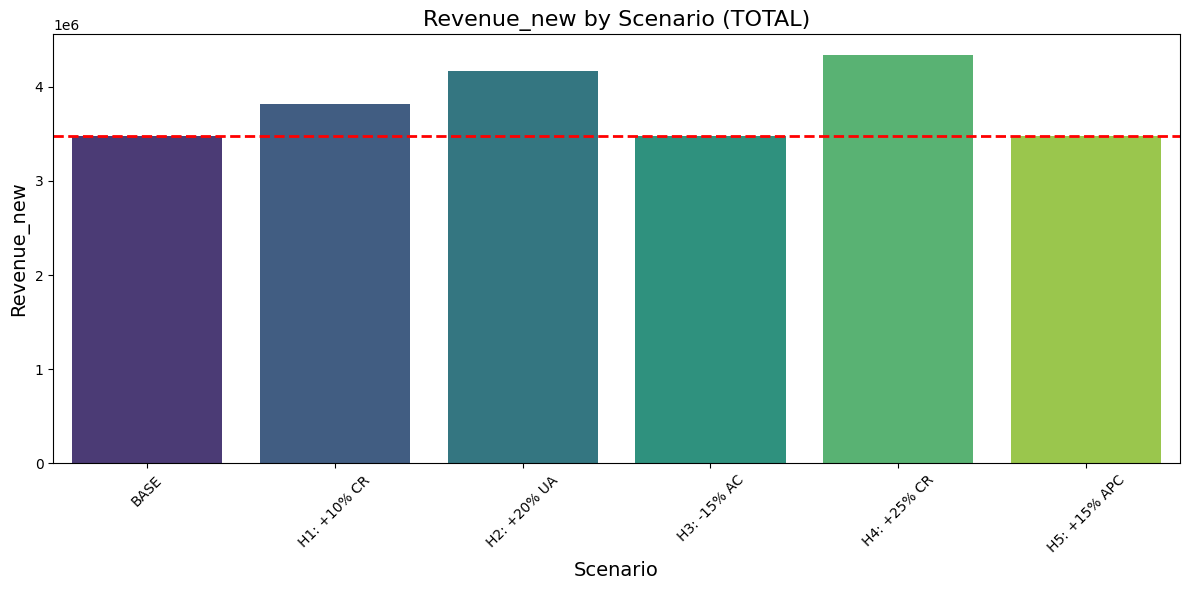

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=totals,
    x="Scenario",
    y="Revenue_new",
    hue="Scenario",
    palette="viridis",
    legend=False,
    errorbar=None
)

plt.axhline(y=base_revenue, color="red", linestyle="--", linewidth=2)
plt.title("Revenue_new by Scenario (TOTAL)", fontsize=16)
plt.xlabel("Scenario", fontsize=14)
plt.ylabel("Revenue_new", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🎯 Scenario Insights
 - H4 (+25% CR) — strongest scenario, maximum impact.

 - H2 (+20% UA) — linear scalable growth.

 - H3 (budget reduction) — best ROI scenario.

 - H5 (+15% APC) — increases LTV and long‑term value.

 - H1 (+10% CR) — fast effect through sales team improvements.

## 📊 Scenario Dashboard (Dash)

In [20]:
import dash
from dash import dcc, html
import plotly.express as px

app = dash.Dash(__name__)

fig_scenarios = px.bar(
    totals,
    x="Scenario",
    y="Revenue_new",
    title="Revenue_new by Scenario (TOTAL)",
    color="Scenario"
)

app.layout = html.Div([
    html.H1("Marketing & Revenue Dashboard"),

    dcc.Tabs([
        dcc.Tab(label="Main KPIs", children=[
            dcc.Graph(
                figure=px.bar(df_sum, x="Product", y="Revenue", title="Revenue by Product")
            ),
            dcc.Graph(
                figure=px.bar(df_sum, x="Product", y="CM", title="Contribution Margin")
            )
        ]),

        dcc.Tab(label="Scenarios", children=[
            dcc.Graph(figure=fig_scenarios)
        ]),

        dcc.Tab(label="Financial Model", children=[
            html.H3("df_sum"),
            dcc.Graph(
                figure=px.bar(df_sum, x="Product", y="UA", title="UA Distribution")
            )
        ])
    ])
])

if __name__ == "__main__":
    app.run(debug=True)

## 💾 13. Saving Results

In [21]:
with pd.ExcelWriter("06_unit_economics_results.xlsx", engine="xlsxwriter") as writer:
    df_sum.to_excel(writer, sheet_name="Unit_Economics_Products", index=False)
    all_scenarios.to_excel(writer, sheet_name="All_Scenarios", index=False)
    totals.to_excel(writer, sheet_name="Totals", index=False)

## 🧹 Final Cleanup Block

In [23]:
drop_deals = ["Term", "Content", "Page", "City_norm"]
drop_calls = ["Scheduled in CRM", "Call Status", "Call Type"]
drop_contacts = ["Email", "Phone", "Created By"]
drop_spend = ["AdGroup", "Ad"]

deals_clean2 = deals.drop(columns=[c for c in drop_deals if c in deals.columns])
calls_clean2 = calls.drop(columns=[c for c in drop_calls if c in calls.columns])
contacts_clean2 = contacts.drop(columns=[c for c in drop_contacts if c in contacts.columns])
spend_clean2 = spend.drop(columns=[c for c in drop_spend if c in spend.columns])

deals_clean2.to_excel("Deals_final.xlsx", index=False)
calls_clean2.to_excel("Calls_final.xlsx", index=False)
contacts_clean2.to_excel("Contacts_final.xlsx", index=False)
spend_clean2.to_excel("Spend_final.xlsx", index=False)

print("✔ All files were successfully cleaned and saved!")

✔ Все файлы очищены и сохранены!
